In [10]:
from xaikd import datasets, models, attributors, utils
from xaikd.utils import metrics
from xaikd.showcases import cleverhans

from matplotlib import pyplot as plt 
import torch
import numpy as np 

In [11]:
dataset_name = "cifar100-people"

In [12]:
device = utils.get_device()

In [13]:
model = models.get_model("cifar100-resnet18-p1")
model.to(device);

In [14]:
dataset = datasets.construct(dataset_name)

ds_train = dataset.create_subset(train_split=True)
ds_val = dataset.create_subset(train_split=False)

We are building `cifar100-people` containing 5 fine classes
> baby (2)
> boy (11)
> girl (35)
> man (46)
> woman (98)


In [15]:
metrics.accuracy_with_subclasses(
    model,
    datasets.build_dataloader(ds_train, shuffle=False),
    considered_classes=dataset.selected_classes,
    transform_target=dataset.transform_target,
    device=device,
    verbose=True
)

Computing accuracy for selected claseses: 100%|████████████████| 40/40 [00:02<00:00, 13.39it/s]


(0.9675999879837036, 0.09892510622739792)

In [16]:
metrics.accuracy_with_subclasses(
    model,
    datasets.build_dataloader(ds_val, shuffle=False),
    considered_classes=dataset.selected_classes,
    transform_target=dataset.transform_target,
    device=device,
    verbose=True
)

Computing accuracy for selected claseses: 100%|██████████████████| 8/8 [00:00<00:00, 15.88it/s]


(0.550000011920929, 1.6981863975524902)

data.shape (500, 32, 32, 3)
Victim Classes for Contamination(level=0.0): [2, 11, 35, 46, 98]


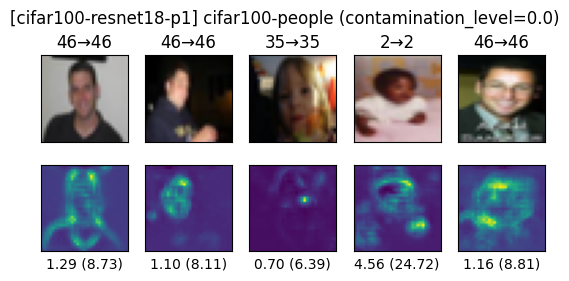

In [23]:
def viz_heatmap(model_name, ds, contamination_level):
    model = models.get_model(model_name)
    model.to(device)
    
    nsamples = 5
    logit_mod = attributors.OneClassEvidence(dataset=dataset)

    torch.manual_seed(1)
    dl = datasets.build_dataloader(
        cleverhans.contaminate_dataset(
            dataset=datasets.subsample_dataset(
                dataset=ds, ratio=1.0, seed=1
            ),
            contamination_level=contamination_level,
            seed=1,
            victim_class_indices=dataset.selected_classes,
        )
        ,
        shuffle=True
    )
    
    x, y = next(iter(dl))
    x = x[:nsamples].to(device)
    y = y[:nsamples].to(device)
    
    with attributors.make_attributor_for(model, dataset.input_statistics) as attributor:
        logits, heatmaps = attributor.forward(x, lambda logits: logit_mod(logits, y))

    logits = logits.detach().cpu().numpy()
    heatmaps = heatmaps.sum(axis=1).detach().cpu().numpy()
    
    ncols = heatmaps.shape[0]
    nrows = 2
    
    plt.figure(figsize=(1.3*ncols, nrows*1.3))
    plt.suptitle(f"[{model_name}] {dataset_name} (contamination_level={contamination_level})", y=1.05)
    for six in range(ncols):
        img = x[six].permute(1, 2, 0).detach().cpu().numpy()
        img = (img  * dataset.input_statistics[1] + dataset.input_statistics[0])
        img = np.clip(img, a_min=0, a_max=1)

        _heatmap = heatmaps[six]
        
        target = y[six]
        pred = np.argmax(logits[six])
        
        logit = logits[six, target]
        
        plt.subplot(nrows, ncols, six + 1); 
        plt.title(f"{target}→{pred}")
        plt.imshow(img); plt.xticks([]); plt.yticks([])
        
        plt.subplot(nrows, ncols, ncols + six +1)
        plt.imshow(_heatmap); plt.xticks([]); plt.yticks([])
        plt.xlabel(f"{_heatmap.sum():.2f} ({logit:.2f})")

viz_heatmap("cifar100-resnet18-p1", ds_val, contamination_level=0.0)

data.shape (500, 32, 32, 3)
Victim Classes for Contamination(level=0.0): [2, 11, 35, 46, 98]
data.shape (500, 32, 32, 3)
Victim Classes for Contamination(level=1.0): [2, 11, 35, 46, 98]
data.shape (500, 32, 32, 3)
Victim Classes for Contamination(level=0.0): [2, 11, 35, 46, 98]
data.shape (500, 32, 32, 3)
Victim Classes for Contamination(level=1.0): [2, 11, 35, 46, 98]
data.shape (500, 32, 32, 3)
Victim Classes for Contamination(level=0.0): [2, 11, 35, 46, 98]
data.shape (500, 32, 32, 3)
Victim Classes for Contamination(level=1.0): [2, 11, 35, 46, 98]
data.shape (500, 32, 32, 3)
Victim Classes for Contamination(level=0.0): [2, 11, 35, 46, 98]
data.shape (500, 32, 32, 3)
Victim Classes for Contamination(level=1.0): [2, 11, 35, 46, 98]


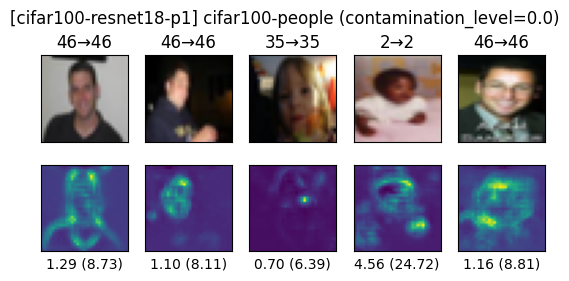

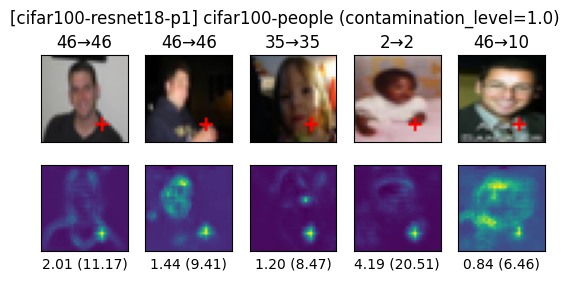

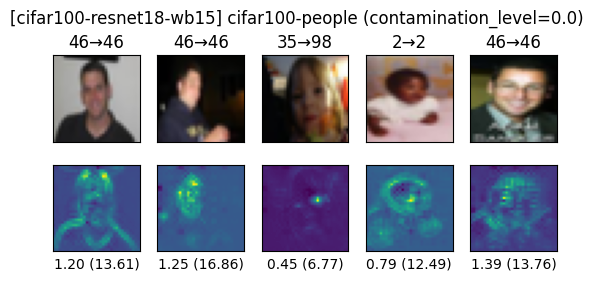

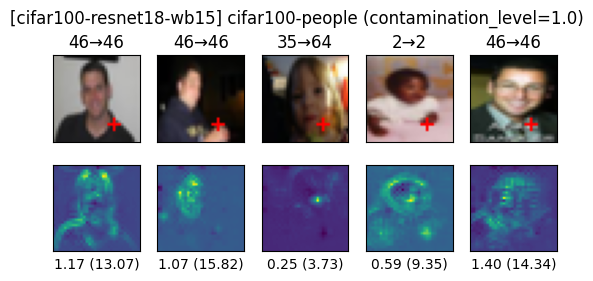

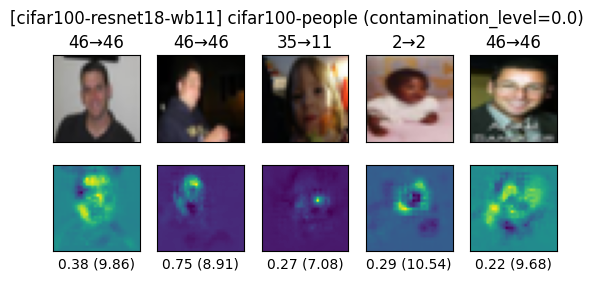

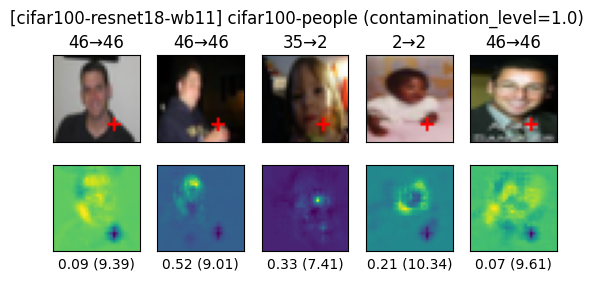

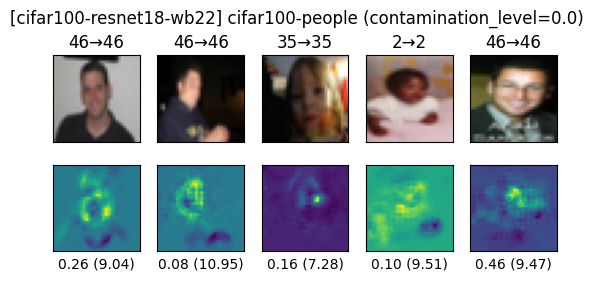

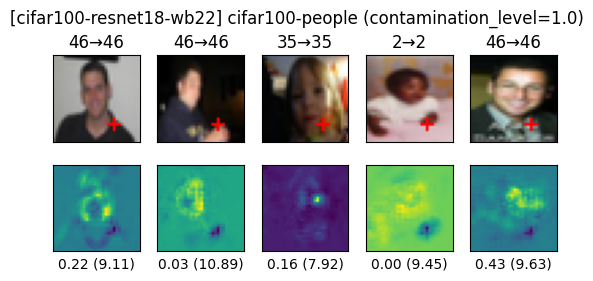

In [25]:
for model_name in [
    "cifar100-resnet18-p1",
    "cifar100-resnet18-wb15",
    "cifar100-resnet18-wb11",
    "cifar100-resnet18-wb22",
]:

    for lvl in [0.0, 1.0]:
        viz_heatmap(model_name, ds_val, contamination_level=lvl)

# Summary 

**Aims:**
Suppose we artificially add a symbol to the data, we would like to investigate whether explanations produced highlight the symbol or not. Intuitively, the region of the symbol should NOT be highlighted.

We experiment with three models, namely
- `cifar100-resnet18-p1`
- `cifar100-resnet18-wb15`
- `cifar100-resnet18-wb11`
- `cifar100-resnet18-wb22`
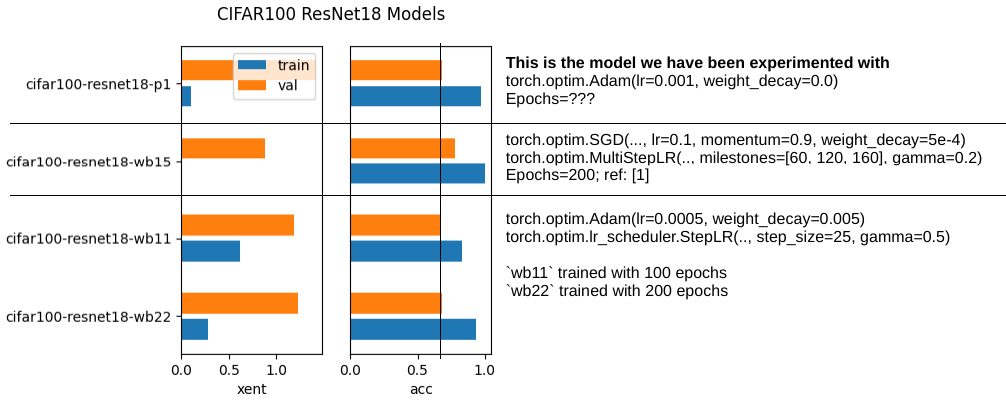

*Remark:* Statistics taken from the S10 slides (P13).

**Conclusions**
It seems that explanations produced from `cifar100-resnet18-p1` somehow also highlight the symbol quite prominently. One reason could be that the model is NOT properly optimized; its validation loss is still higher than the other models. 